# Variational Auto-Encoder

## Preambule

In this practical session, we will keep using tensorflow custom models but we won't need to go into the same level of details as compared to the previous lab. Indeed, we won't need to use the `torch.Tensor` class for the trainable parameters and we will directly instantiate layers. It remains more covenient to use a custom model because we will need a sampling layer and a custom loss.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

## Preliminaries

As usual, we will be using the `MNIST` dataset. Import this dataset using `torchvision` functions.

In [2]:
##################
# Dataset import #
##################
data_preprocessing_transform = transforms.Compose([transforms.ToTensor(),transforms.Lambda(lambda x: torch.flatten(x, start_dim=1))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=data_preprocessing_transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=data_preprocessing_transform)

# Use a dummy dataloader to gain access to the entire dataset at once
# A dataloader is a generator, so we can associate an iterator iter() to it.
# Once the iterator is in place we ask for the first batch next() that returns the set of samples and the set of labels
x_train,y_train = next(iter(DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=False)))
x_test,y_test = next(iter(DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)))

# DataLoader did the work !
print("Unprocessed dataset shape:", train_dataset.data.shape)
print("Preprocessed dataset shape: ", x_train.shape)

# Constants
n = len(train_dataset)
h, w = train_dataset.data[0].shape[0], train_dataset.data[0].shape[1]
d_inputs = 28 * 28
d_z = 2 # codings
n_class = 10

Unprocessed dataset shape: torch.Size([60000, 28, 28])
Preprocessed dataset shape:  torch.Size([60000, 1, 784])


In the above lines, we have defined the usual constants : `n` is the dataset size, we use inputs that are 28 x 28 images so the dimensionality of inputs `d_inputs` is equal to 784. In `MNIST`, there are 10 classes. Finally `d_z` is the dimensionality of the latent variable $\mathbf{z}$ used as part of the VAE model. Please observe that now the data is mapped to 0..1 intensity space.

## Main exercise

We are now ready to start writing some code to illustrate the possibilities offered by **variational auto-encoders** (VAEs).  There is quite a lot of work to do to obtain a VAE: 
* build an encoder network that yields $\boldsymbol\mu_{z|x}$ and $\boldsymbol\Sigma_{z|x}$, the parameters of the Gaussian conditional distribution of the latent representation $p(\mathbf{z}|\mathbf{x})$,

$$  \mathbf{z}|\mathbf{x} \sim \mathcal{N}\left( \boldsymbol\mu_{z|x}, \boldsymbol\Sigma_{z|x} \right) $$

* sample from $p \left( \mathbf{z} | \mathbf{x} \right)$ using `torch` functionalities,
* build a decoder network that yields the parameters of the distribution $p \left( \mathbf{x} | \mathbf{z} \right)$ which is also Gaussian,
* train these networks together by minimizing the VAE loss,
* test the reconstruction ability of the trained VAE on test images.

We will make a number of simplifying hypotheses to help us designing a VAE that will not overfit or diverge. We will discuss each step separately.

### Encoder

Remember that we are not learning the parameters of the true posterior distribution $p \left( \mathbf{z}|\mathbf{x} \right)$ but instead ... we are learning **variational parameters** $\boldsymbol\phi$ which are obtained as the output of some network (the encoder) and $q_{\boldsymbol\phi \left(\mathbf{x}\right)}$ is meant to be an approximation of the posterior distribution $p \left( \mathbf{z}|\mathbf{x} \right)$. 

Assuming that the posterior is Gaussian, mean and covariance matrix are sufficient statistics. To make things easier we set 

$$ \boldsymbol\Sigma_{z|x} = \text{Diag}\left( \boldsymbol \sigma_{z|x} \right)^2 ,$$

where $\boldsymbol \sigma_{z|x}^2$ is a vector with same size as $\boldsymbol\mu_{z|x}$, i.e. the latent space dimensionality. This dimensionality is saved in variable `d_z` which will be an attribute of the new `class VAE` that we will design in this practical session. This class inherits the `torch.nn.Module` similarly as in the previous lab. 
To explain what architecture we want, we will use a list of integers `architecture` containing the number of components of the inputs followed by the number of units in the neural layers of the encoder. So if $K$ is the number of layers of the encoder, it means that `len(architecture)` is equal to $K+1$. In particular :
* `architecture[0]` is equal to `d_inputs`,
* `architecture[-1]` is equal to `d_z`. 

The architecture of the decoder is omitted (because it is deduced from that of the encoder). However, we will not tie paremeters of the encoder and decoder this time.

**Q1** Fill the missing code section of the constructor `__init__` of the class `VAE` so that each layer has appropriate size. We will use fully connected layers in this lab which are instances of `torch.nn.Linear`. For the decoder, make sure to scroll `architecture` backward so that we obtain the desired archictecture symmetry of auto-encoders. Also, the dimension of outputs should be equal to the dimension of inputs.


**Q2** Fill the gaps in the `__call__` method of the class `VAE` in order to obtain $\boldsymbol\mu_{z|x}$ and $\log\boldsymbol \sigma_{z|x}^2$ from inputs. These lines of code correspond to the computation path of the encoder. You will need a `for` loop on the number of layers. The encoder has two outputs ($\boldsymbol\mu_{z|x}$ and $\log \boldsymbol \sigma_{z|x}^2$). 
This means that the last layer of the encoder is a fork ! We will use a python dict to encapsulate the two branches of the fork (one for the expectation and one for the log variance).

**rq**: the network yields $\color{red} \log\boldsymbol \sigma_{z|x}^2$ instead of $\boldsymbol\sigma_{z|x}^2$ because $\log$ maps positive reals to $[-\infty, +\infty]$ which is compatible with the output of a neural net layer.


### Sampling from $q_{\phi} \approx p \left( \mathbf{z}|\mathbf{x} \right)$

In the VAE setting, the next step consists in sampling from $q_{\phi} \left( \mathbf{z}|\mathbf{x} \right)$ for each input $\mathbf{x}$ in the current mini-batch. This is necessary to obtain an MC approximation of the cross-entropy term of the loss. The usual practice consists in drawing only one sample $\mathbf{z}$ for each input (a quite coarse MC approximation but usually sufficient for converging to a relevant model).

A difficulty with this step is that it is not obvious how to differentiate the sampled $\mathbf{z}$ w.r.t. the encoder parameters so we cannot backprop... ☹️

But, using the **re-parametrization trick**, everything is back in order ! Let $\boldsymbol\epsilon \sim \mathcal{N}\left(\mathbf{0},\mathbf{I}\right)$. We have

$$ \boldsymbol\mu_{z|x} + \boldsymbol\sigma_{z|x}\odot\boldsymbol\epsilon \sim \mathcal{N}\left(\boldsymbol\mu_{z|x},\text{Diag}\left(\boldsymbol\sigma_{z|x}\right)\right) ,$$

where $\odot$ is the Hadamard product (or elementwise product). It is not problematic not to be able to differentiate $\boldsymbol\epsilon$ because it is not part of the model that we need to train, but what is nice, is that the randomization is now isolated in the computational graph and both $\boldsymbol\mu_{z|x}$ and $\boldsymbol\sigma_{z|x}$ are now explicitely connected to the sampled $\mathbf{z}$ which can now be differentiated w.r.t. them.

**Q3** Add lines of code to the `__call__` method to implement the re-parametrization trick. You can use `torch.randn` to sample the $\boldsymbol\epsilon$.

For practical resaons, the obtained sample is saved as `self.z` (an attribute of the `VAE` class).

### Decoder

Theoretically speaking, we should build another network whose outputs are $\boldsymbol\mu_{x|z}$ and $\boldsymbol\Sigma_{x|z}$ and sample from the corresponding Gaussian to obtain reconstructed inputs $\hat{\mathbf{x}}$. 

Let's again make things a lot more simple and set $\boldsymbol\Sigma_{x|z}=\mathbf{I}$. This choice will make the decoder much more simple (and thus easier to train). Also, we see that it is not really interesting to implement the sampling step because if we know $\boldsymbol\mu_{x|z}$, then we can easily sample from $\mathcal{N}\left(\boldsymbol\mu_{x|z} ,\mathbf{I}\right)$ by adding $\boldsymbol\mu_{x|z}$ and a sample from $\mathcal{N}\left(\mathbf{0} ,\mathbf{I}\right)$!

So let us focus on $\boldsymbol\mu_{x|z}$ which will be the sole output of the decoder network. 

**Q4** Assuming a mirror architecture w.r.t. the encoder, implement the `decoder` method which is called inside `__call__` in order to obtain the network output. The decoding part of the network has to be implemented in a separate function because it will be invoked also for generating new inputs (see questions at the end of the practical).


In [3]:
class VAE(nn.Module):
    def __init__(self, architecture, learning_rate=1e-4, name=None, activation=torch.nn.ReLU):
        super(VAE,self).__init__()
        self.enc_layers = nn.Sequential()
        self.dec_layers = nn.Sequential()
        self.dx = architecture[0] #input space dim
        self.dz = architecture[-1] #latent space dim
        self.K = len(architecture) - 1 #number of layers in encoder (or decoder)
        #encoder
        for i in range(self.K):          
            if (i < self.K - 1):
                self.enc_layers.append(
                        nn.Sequential(nn.Linear
                                      (in_features=architecture[i], out_features=architecture[i+1]),
                                      activation()
                        )
                )
            else:
                final_layer = nn.ModuleDict()
                final_layer["esp"] = nn.Sequential(nn.Linear(in_features=architecture[i], out_features=architecture[i+1]), activation())
                final_layer["sig"] = nn.Linear(in_features=architecture[i], out_features=architecture[i+1]) 
                self.enc_layers.append(final_layer)
                
        #decoder
        for i in range(self.K):            
            self.dec_layers.append(
                        nn.Sequential(nn.Linear
                                      (in_features=architecture[self.K-i],out_features=architecture[self.K-i-1]),
                                      activation()
                        )
            )

    def __call__(self, x):
        z_enc = [x]
        #encoding
        for i in range(self.K): 
            if (i < self.K-1):
                z_enc.append(self.enc_layers[i](z_enc[-1]))
            else:
                esp_z_given_x = self.enc_layers[i]["esp"](z_enc[-1])
                log_sigma_sq_z_given_x = self.enc_layers[i]["sig"](z_enc[-1])

        #sampling in latent space
        sample = torch.randn(self.dz, dtype=torch.float32) #it samples from N(O,1) distribution
        self.z = esp_z_given_x + torch.exp(0.5 * log_sigma_sq_z_given_x) * sample
        
        #decoding
        return (self.decode(), esp_z_given_x, log_sigma_sq_z_given_x)
        
    def decode(self, z=None):
        if z is None:
            z_dec = [self.z]
        else:
            z_dec = [z]
        
        for i in range(self.K):  
            z_dec.append(self.dec_layers[i](z_dec[-1]))
        
        return z_dec[-1]         

**Q5** Instanciate a VAE having 3 hidden layers with 256, 128 and 64 neurons. The dimension of the hidden embedding is still 2.

Check by printing out the instance of the VAE that you have obtained the desired number of layers and neurons.

Check that when you apply the VAE on a sample it generates well a reconstructed image having the same shape as the input image and that the `esp_z_given_x`, `log_sigma_sq_z_given_x` shape is coherent with the value of `d_z`

In [4]:
architecture = [d_inputs, 256, 128, 64, d_z]
my_VAE = VAE(architecture)

In [5]:
print(my_VAE)

VAE(
  (enc_layers): Sequential(
    (0): Sequential(
      (0): Linear(in_features=784, out_features=256, bias=True)
      (1): ReLU()
    )
    (1): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): ReLU()
    )
    (2): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
    )
    (3): ModuleDict(
      (esp): Sequential(
        (0): Linear(in_features=64, out_features=2, bias=True)
        (1): ReLU()
      )
      (sig): Linear(in_features=64, out_features=2, bias=True)
    )
  )
  (dec_layers): Sequential(
    (0): Sequential(
      (0): Linear(in_features=2, out_features=64, bias=True)
      (1): ReLU()
    )
    (1): Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): ReLU()
    )
    (2): Sequential(
      (0): Linear(in_features=128, out_features=256, bias=True)
      (1): ReLU()
    )
    (3): Sequential(
      (0): Linear(in_features=256, out_features=784, bias=T

In [6]:
print(my_VAE(train_dataset[0][0])[0].shape)  # CHECK reconstructed image shape
print(my_VAE(train_dataset[0][0])[1].shape)  # CHECK esp_z_given_x and log_sigma_sq_z_given_x shape
print(my_VAE(train_dataset[0][0])[2].shape)

torch.Size([1, 784])
torch.Size([1, 2])
torch.Size([1, 2])


### Building the loss

We cannot launch training until a loss is specified. So we need to explain `torch` how to compute the loss from the network output and other intermediate computations.

Let us recap what we need to optimize in the VAE setting. We are maximizing a lower of bound of the expected log-likelihood, this lower bound being referred to as ELBO. The ELBO is the sum of two terms: a cross-entropy term and a KL term.

#### Cross-entropy term

This term is given by 

$$ \mathbb{E}_{z\sim q_{\phi}\left( .|\mathbf{x} \right) } \left[ \log p \left( \mathbf{x}|\mathbf{z} \right) \right]. $$

If $\mathbf{z}^{(i)}$ is a sample obtained from $q_{\phi}\left( .|\mathbf{x} \right)$, then $\log p \left( \mathbf{x}|\mathbf{z}^{(i)} \right)$ is a crude MC approximation of the above expectation. If $\mathbf{x}|\mathbf{z} \sim \mathcal{N}\left(\boldsymbol\mu_{x|z} ,\mathbf{I}\right)$, then by definition, we have 

$\begin{align}\log p \left( \mathbf{x}|\mathbf{z}^{(i)} \right) &= -\frac{1}{2} \left(\mathbf{x}- \boldsymbol\mu_{x|z}\right)^T \cdot \mathbf{I} \cdot \left(\mathbf{x}- \boldsymbol\mu_{x|z}\right) + ct \\
&=-\frac{1}{2} \lVert \mathbf{x}-\boldsymbol\mu_{x|z} \rVert_2^2 + ct. \end{align} $

So maximizing this term is tantamount to minimizing "good old" $L_2$-reconstruction loss because $\boldsymbol\mu_{x|z}$ is the expected reconstructed input!

**Q6** Fill the `loss` method of the `VAE` class in order to compute the cross-entropy term for some input tensor `x`. The additive constant $ct$ can be omitted. 

#### KL term

The KL terms writes 

$$ d_{\text{KL}} \left( q_{\boldsymbol\phi} || p\left(\mathbf{z}\right) \right). $$

We thus need to specify a prior for $\mathbf{z}$. A convenient choice is $\mathbf{z} \sim \mathcal{N}\left(\mathbf{0},\mathbf{I}\right)$. A KL between two Gaussians can be computed in closed form. We can show that 

$$ d_{\text{KL}} \left( q_{\boldsymbol\phi} || p\left(\mathbf{z}\right) \right) = -\frac{1}{2}\left( \sum_j 1+  \log\sigma_{z|x,j}^2 - \sigma_{z|x,j}^2 - \mu_{z|x,j}^2\right) $$

**Q6** Add instructions at the end of the `loss` method allowing to compute the KL term. We are now ready to return the loss value which is $-1 \times $ the cross-entropy $+$ KL because it will be minimized by `torch`.

In [7]:
def loss(model, x):
    x_hat, esp, log_sigma = model(x)

    # reconstruction (cross-entropy) term
    cross_ent_term = -0.5 * torch.sum((x - x_hat) ** 2)

    # KL divergence term
    kl_term = -0.5 * torch.sum(
        1 + log_sigma - torch.exp(log_sigma) - esp ** 2
    )

    return -cross_ent_term + kl_term, cross_ent_term, kl_term

**Q7** Compute and print out the loss and its components for the first 10 images of the train set.

In [8]:
for i in range(10):
    print(loss(my_VAE, train_dataset[i][0]))

(tensor(43.4861, grad_fn=<AddBackward0>), tensor(-43.4811, grad_fn=<MulBackward0>), tensor(0.0049, grad_fn=<MulBackward0>))
(tensor(49.2184, grad_fn=<AddBackward0>), tensor(-49.2141, grad_fn=<MulBackward0>), tensor(0.0043, grad_fn=<MulBackward0>))
(tensor(28.9170, grad_fn=<AddBackward0>), tensor(-28.9131, grad_fn=<MulBackward0>), tensor(0.0039, grad_fn=<MulBackward0>))
(tensor(28.2930, grad_fn=<AddBackward0>), tensor(-28.2875, grad_fn=<MulBackward0>), tensor(0.0055, grad_fn=<MulBackward0>))
(tensor(37.0057, grad_fn=<AddBackward0>), tensor(-36.9985, grad_fn=<MulBackward0>), tensor(0.0072, grad_fn=<MulBackward0>))
(tensor(45.2876, grad_fn=<AddBackward0>), tensor(-45.2816, grad_fn=<MulBackward0>), tensor(0.0059, grad_fn=<MulBackward0>))
(tensor(29.8321, grad_fn=<AddBackward0>), tensor(-29.8263, grad_fn=<MulBackward0>), tensor(0.0058, grad_fn=<MulBackward0>))
(tensor(58.1297, grad_fn=<AddBackward0>), tensor(-58.1256, grad_fn=<MulBackward0>), tensor(0.0041, grad_fn=<MulBackward0>))
(tensor(


**Q8** We will use the function `test_reconstruction` to display an image like the following:

![T](reconst.png)

It contains (reconstructed input/input) pairs. At the beginning the reconstructed inputs are not at all reflecting the inputs. We will generate such an image at the end of each epoch in order to keep track of qualitative improvements, besides quantitative improvements provided by the loss term.

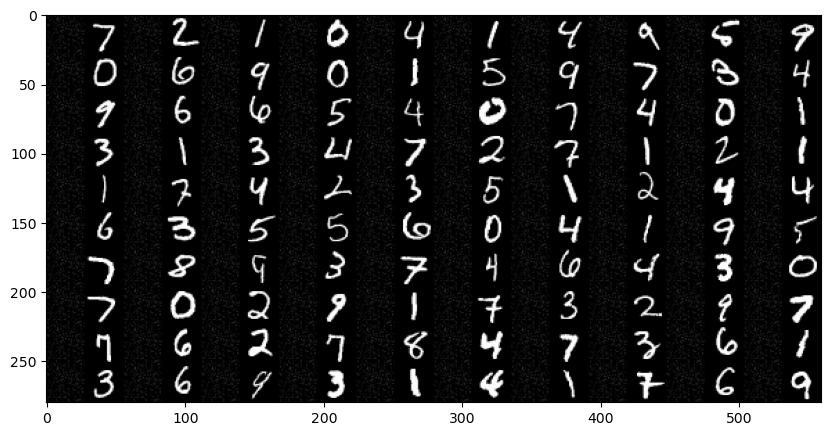

In [9]:
def test_reconstruction(model, x_test, h=28, w=28, batch_size=100):
    # Test the trained model: reconstruction
    x_batch = x_test[:batch_size]
    y_batch = y_test[:batch_size]
    res=model(x_batch)
    x_reconstructed = res[0]
    x_reconstructed.detach().numpy()
    n = np.sqrt(batch_size).astype(np.int32)
    I_reconstructed = np.empty((h*n, 2*w*n))
    for i in range(n):
        for j in range(n):
            x = np.concatenate(
                (x_reconstructed[i*n+j, :].detach().numpy().reshape(h, w), 
                 x_batch[i*n+j, :].detach().numpy().reshape(h, w)),
                axis=1
            )
            I_reconstructed[i*h:(i+1)*h, j*2*w:(j+1)*2*w] = x
    
    plt.figure(figsize=(10, 20))
    plt.imshow(I_reconstructed, cmap='gray')
    
test_reconstruction(my_VAE, x_test)

We now need to implement the usual training loop for minibatch gradient descent. 

**Q9** Fill the missing lines in the `train_procedure` method and launch a training. Start with a small number of epochs (2) to check that the training is behaving normally (loss decreasing). You can set the number of epochs to 20-30 after this sanity check.

In [10]:
def train_procedure(model, train_dataset, test_dataset, n_epochs=20, batch_size=64, learning_rate=1e-3):
    
    # Define the optimizer
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Define the learning rate scheduler
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.96)
    
    train_loader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader=DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    train_loss_history=[]
    train_cross_loss_history=[]
    train_kl_loss_history=[]
    
    test_loss_history=[]
    test_cross_loss_history=[]
    test_kl_loss_history=[]
    
    steps=len(train_dataset) // batch_size + 1
    for epoch in range(n_epochs):
        model.train()
        for step, (images, labels) in enumerate(train_loader):
            optimizer.zero_grad()
            train_loss, cross, kl = loss(model, images)
            train_loss.backward()
            optimizer.step()
            
            print("\rEpoch %d - %d%% - \tTot=%.5f \tCE=%.5f \tKL=%.5f" % (epoch, int(step/steps*100), train_loss.item(), -cross.item(), kl.item()),end="\r")

        scheduler.step()  # One per epoch
        
        model.eval()

        test_reconstruction(model, x_test)
        plt.pause(1)

        with torch.no_grad():
            total,cel,kl=loss(model,x_train)
            train_loss_history.append(total.item())
            train_cross_loss_history.append(cel.item())
            train_kl_loss_history.append(kl.item())
            
            total,cel,kl=loss(model,x_test)
            test_loss_history.append(total.item())
            test_cross_loss_history.append(cel.item())
            test_kl_loss_history.append(kl.item())
    return (train_loss_history, train_cross_loss_history, train_kl_loss_history,
            test_loss_history, test_cross_loss_history, test_kl_loss_history)

Epoch 0 - 99% - 	Tot=934.06976 	CE=905.57855 	KL=28.4912139

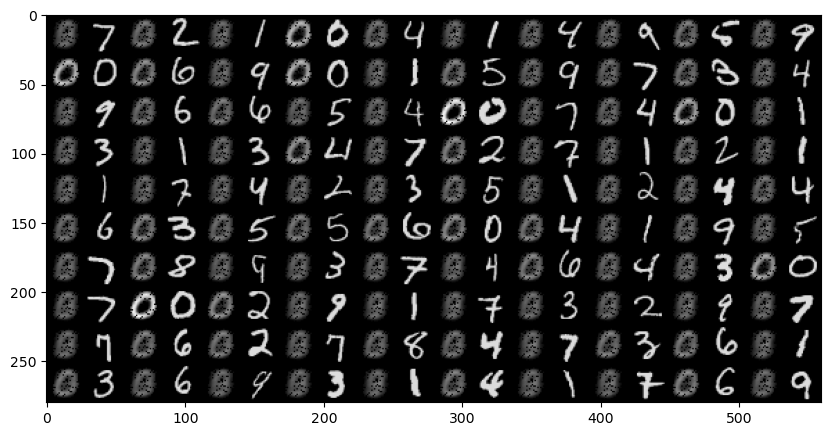

Epoch 1 - 99% - 	Tot=875.75543 	CE=855.16577 	KL=20.5896555

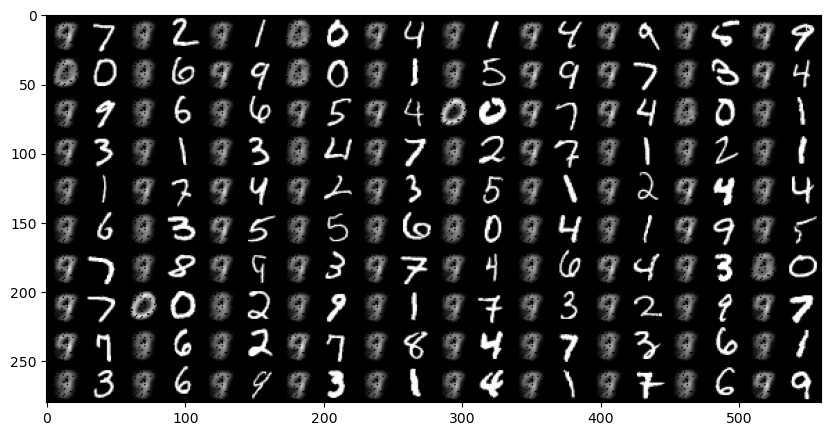

Epoch 2 - 99% - 	Tot=813.68024 	CE=769.19208 	KL=44.48817676

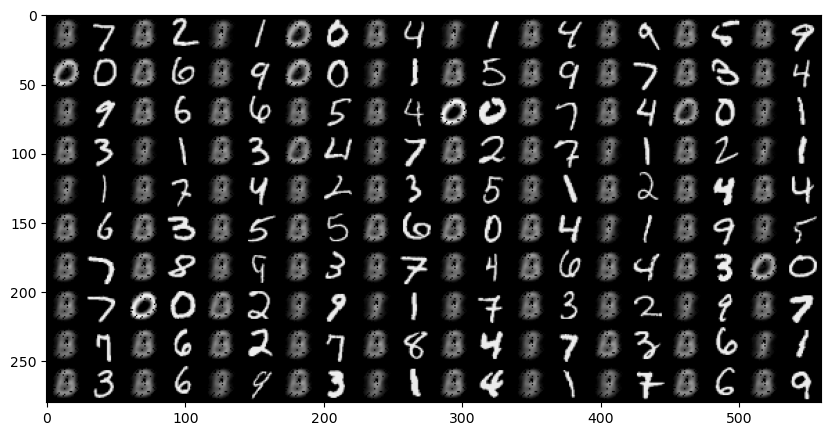

Epoch 3 - 99% - 	Tot=797.80920 	CE=753.60541 	KL=44.20382699

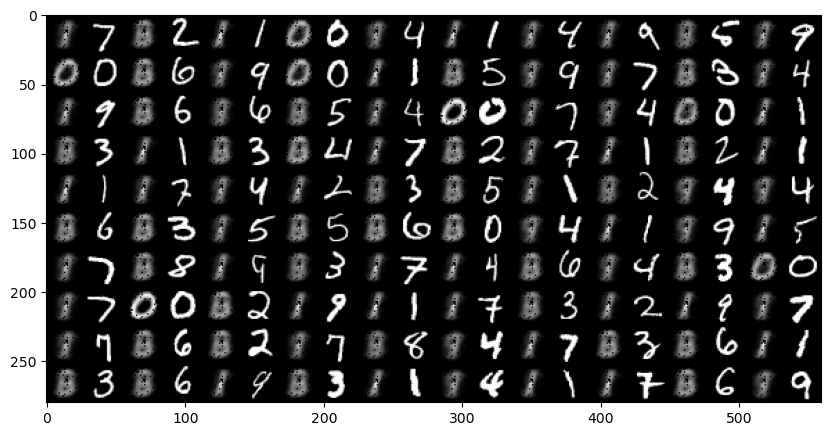

Epoch 4 - 99% - 	Tot=990.97552 	CE=957.59375 	KL=33.38176417

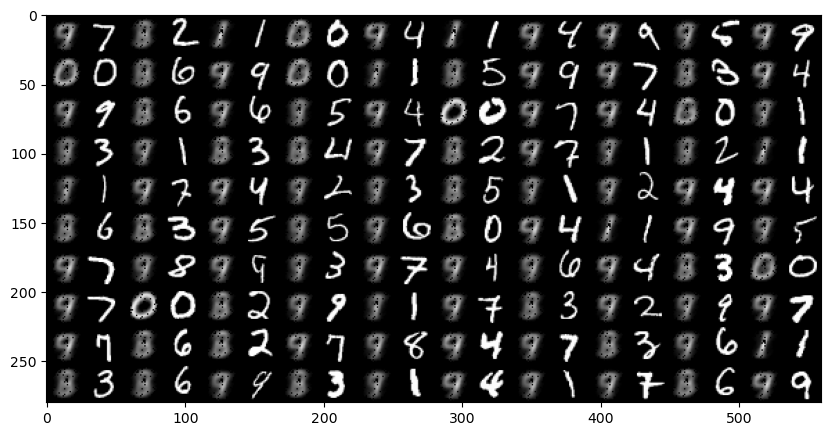

Epoch 5 - 99% - 	Tot=830.99146 	CE=775.46338 	KL=55.52808567

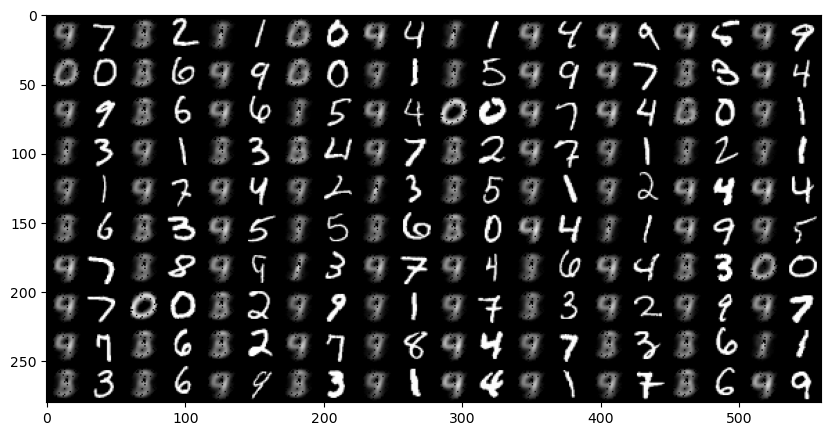

Epoch 6 - 99% - 	Tot=772.98700 	CE=732.19794 	KL=40.78907613

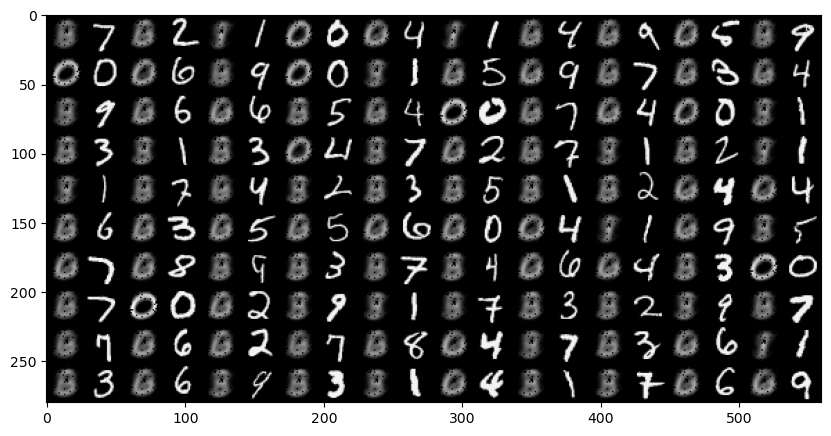

Epoch 7 - 99% - 	Tot=947.09491 	CE=909.67957 	KL=37.41533800

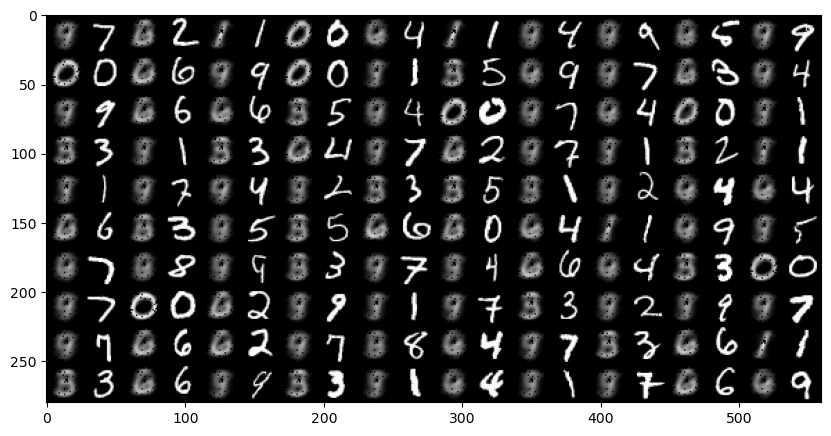

Epoch 8 - 99% - 	Tot=800.61188 	CE=733.67352 	KL=66.93837262

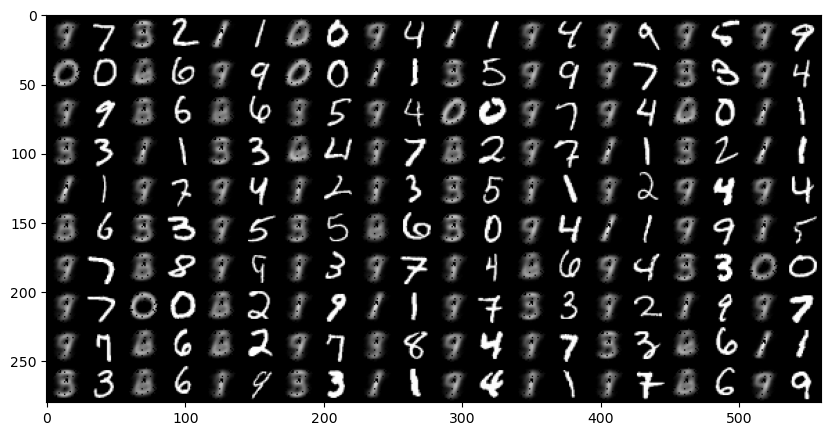

Epoch 9 - 99% - 	Tot=779.82959 	CE=712.61481 	KL=67.21478606

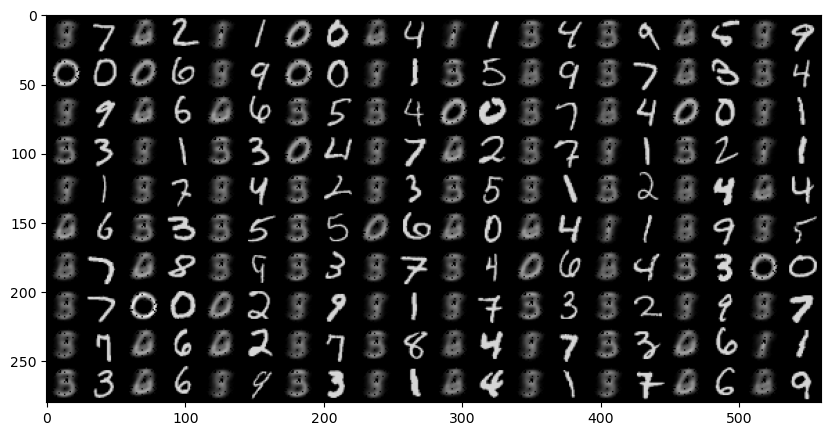

Epoch 10 - 99% - 	Tot=826.24030 	CE=754.13409 	KL=72.10622252

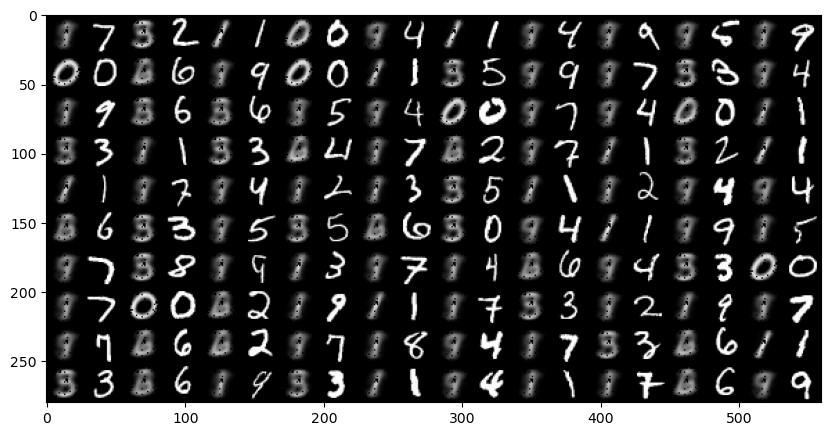

Epoch 11 - 99% - 	Tot=877.43890 	CE=812.74109 	KL=64.69782685

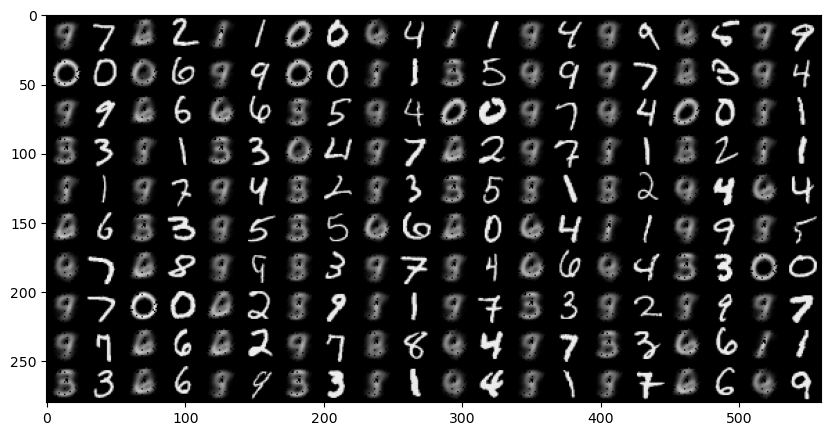

Epoch 12 - 99% - 	Tot=748.52991 	CE=688.70599 	KL=59.82392019

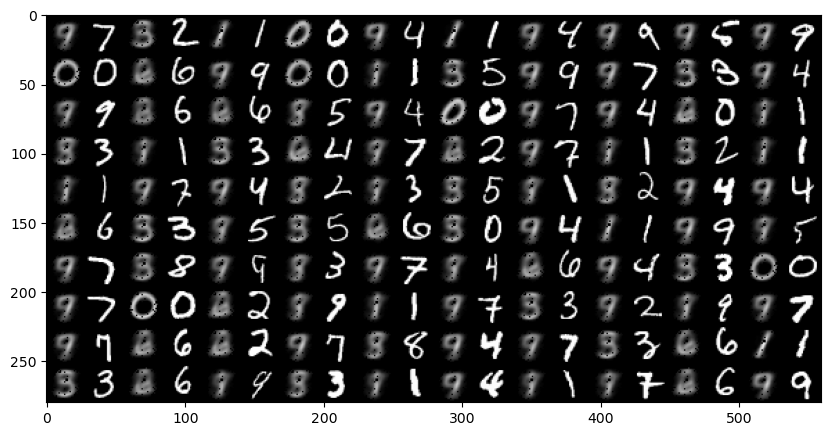

Epoch 13 - 99% - 	Tot=777.06934 	CE=704.95862 	KL=72.11070213

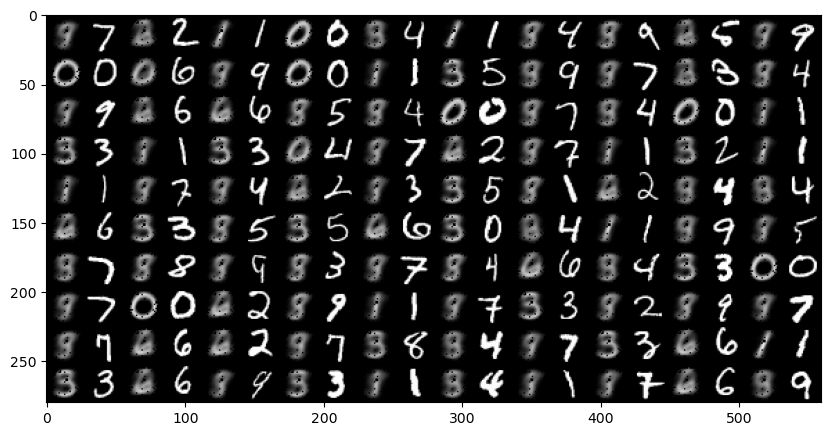

Epoch 14 - 99% - 	Tot=769.56415 	CE=701.51849 	KL=68.04567123

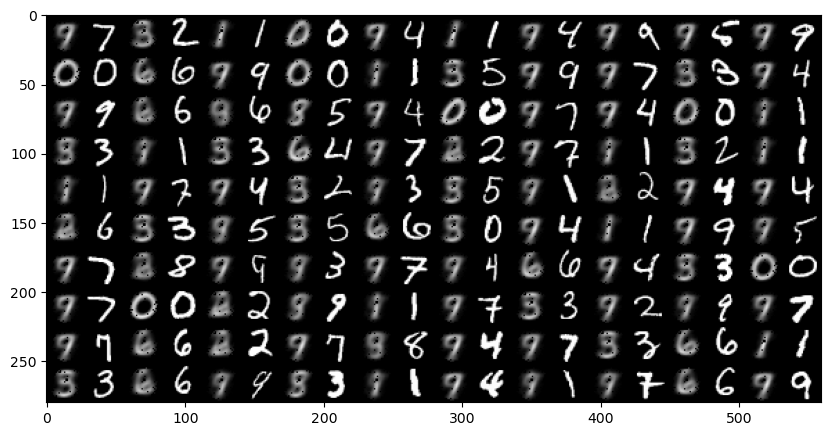

Epoch 15 - 99% - 	Tot=792.64374 	CE=714.35315 	KL=78.29061535

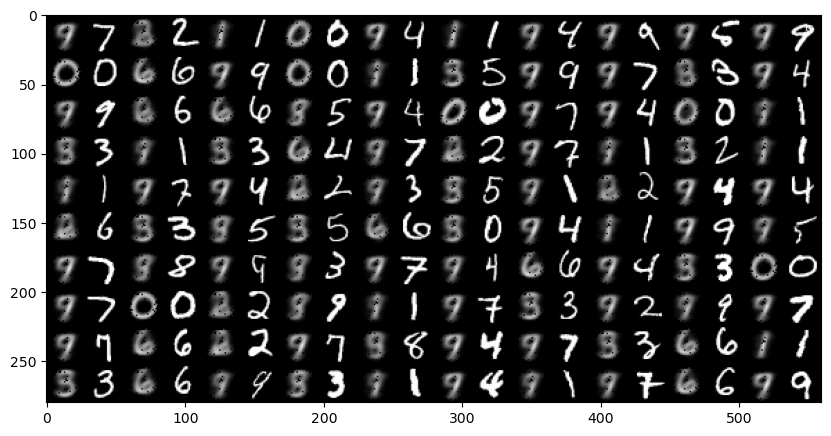

Epoch 16 - 99% - 	Tot=768.55676 	CE=678.75116 	KL=89.80563414

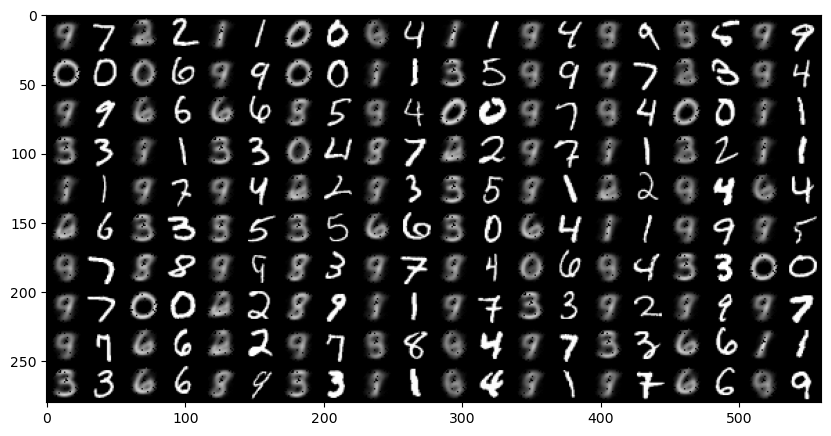

Epoch 17 - 99% - 	Tot=771.58105 	CE=682.03717 	KL=89.54388266

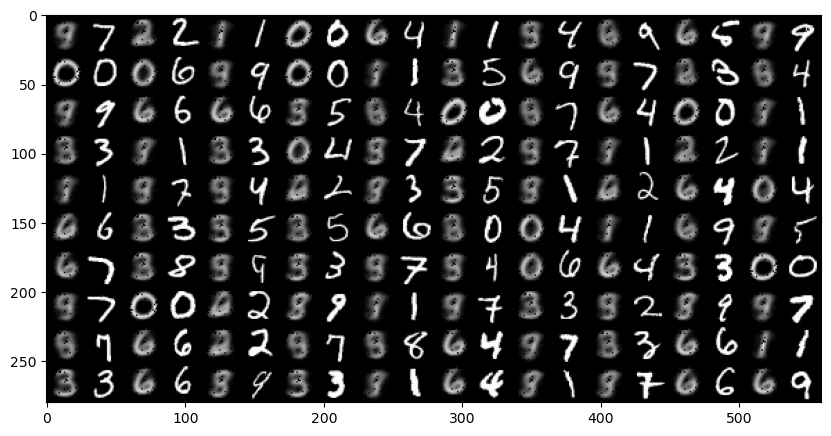

Epoch 18 - 99% - 	Tot=794.57166 	CE=729.88141 	KL=64.69024847

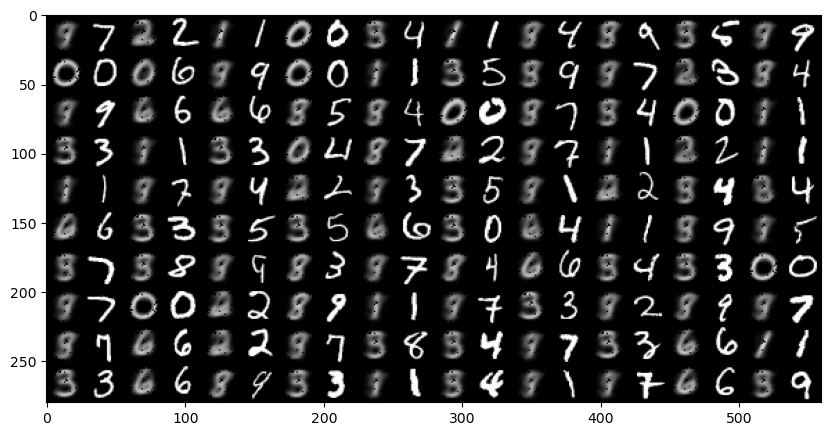

Epoch 19 - 99% - 	Tot=855.80676 	CE=766.25366 	KL=89.55309837

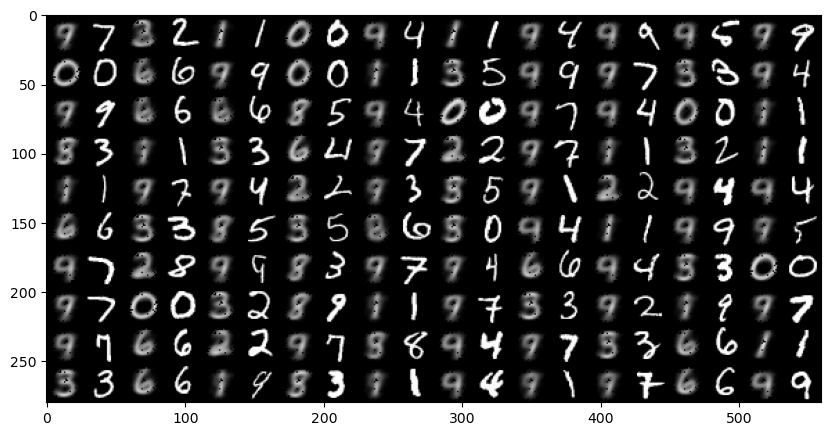

Epoch 20 - 99% - 	Tot=815.09039 	CE=719.30414 	KL=95.78628021

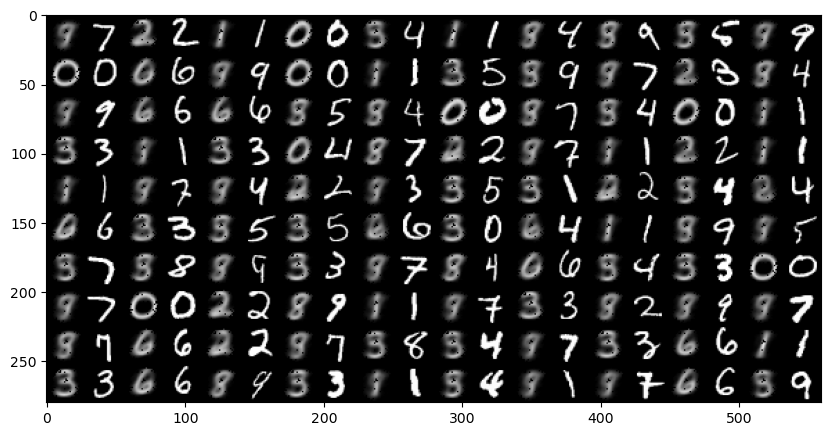

Epoch 21 - 99% - 	Tot=836.77991 	CE=746.67926 	KL=90.10068543

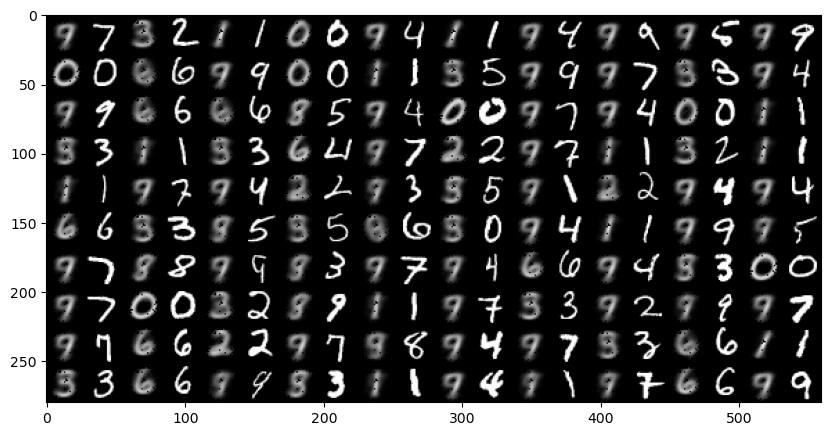

Epoch 22 - 99% - 	Tot=800.57458 	CE=708.35779 	KL=92.21677892

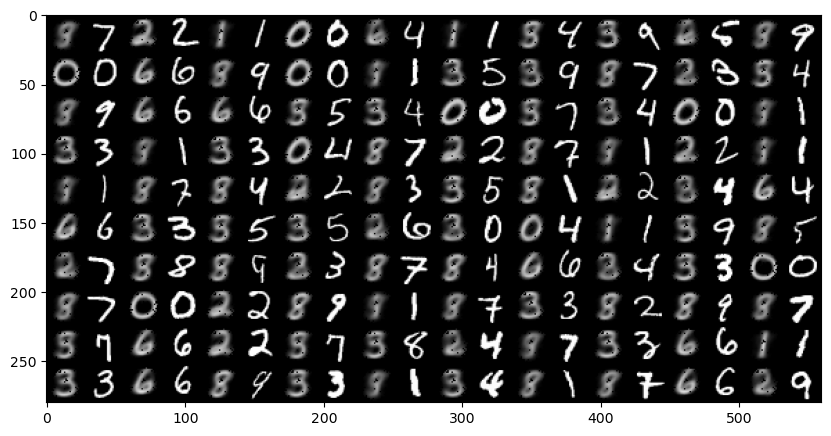

Epoch 23 - 99% - 	Tot=810.51642 	CE=719.81238 	KL=90.70406271

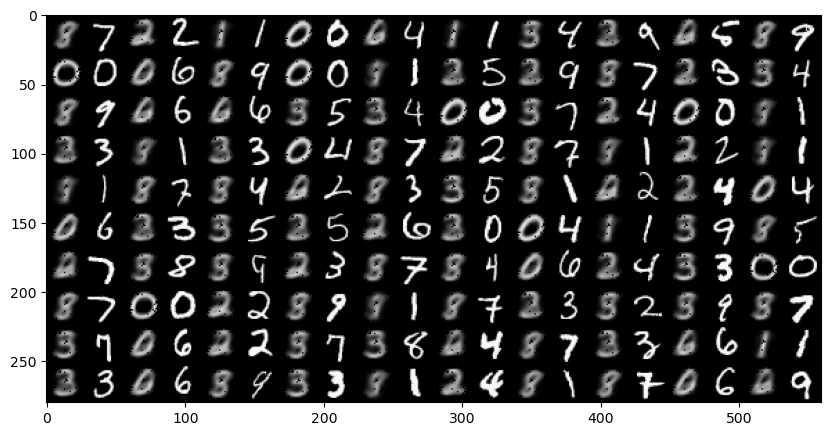

Epoch 24 - 99% - 	Tot=689.94269 	CE=598.27228 	KL=91.67039572

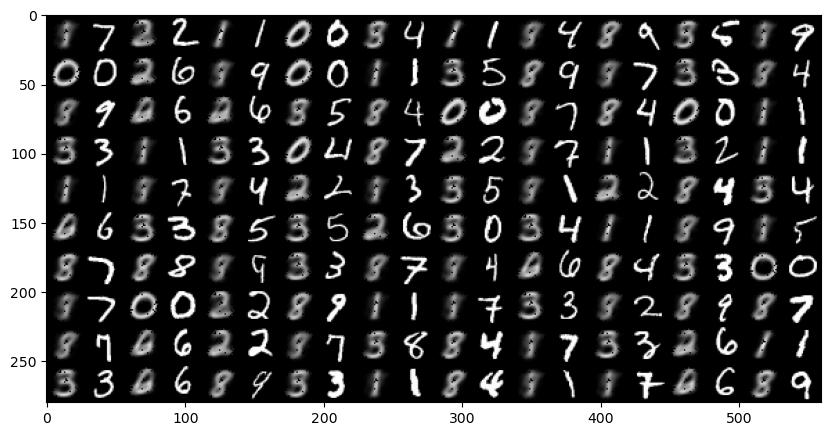

Epoch 25 - 99% - 	Tot=775.08905 	CE=687.73895 	KL=87.35012196

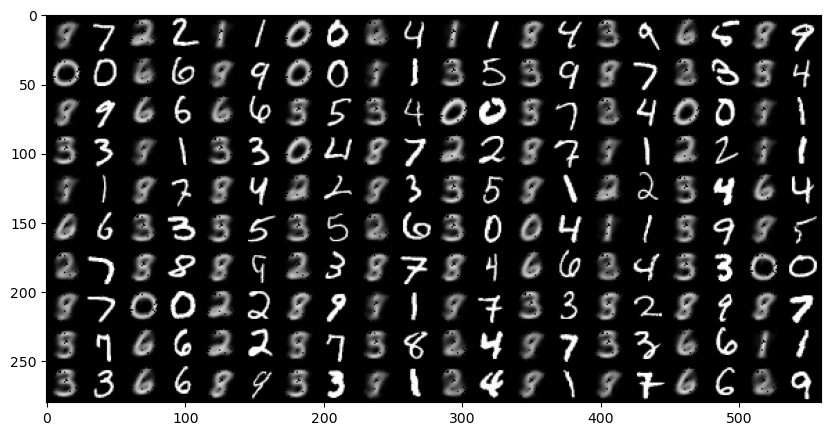

Epoch 26 - 99% - 	Tot=751.28131 	CE=674.30054 	KL=76.98077638

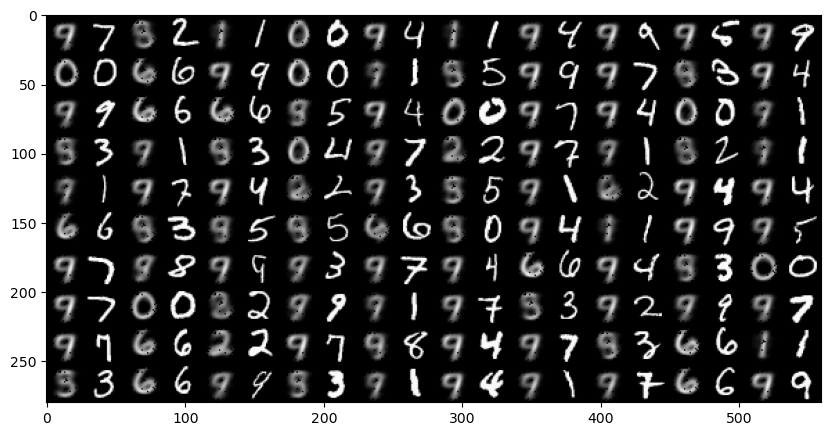

Epoch 27 - 99% - 	Tot=741.68921 	CE=645.34277 	KL=96.34642150

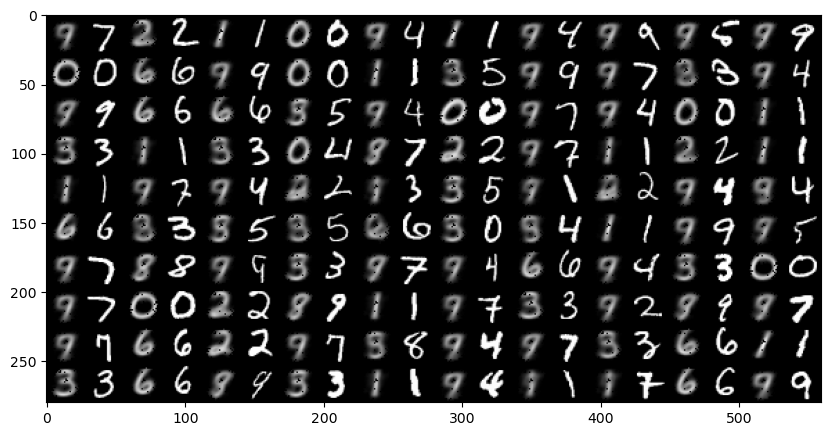

Epoch 28 - 99% - 	Tot=828.86682 	CE=736.18103 	KL=92.68580728

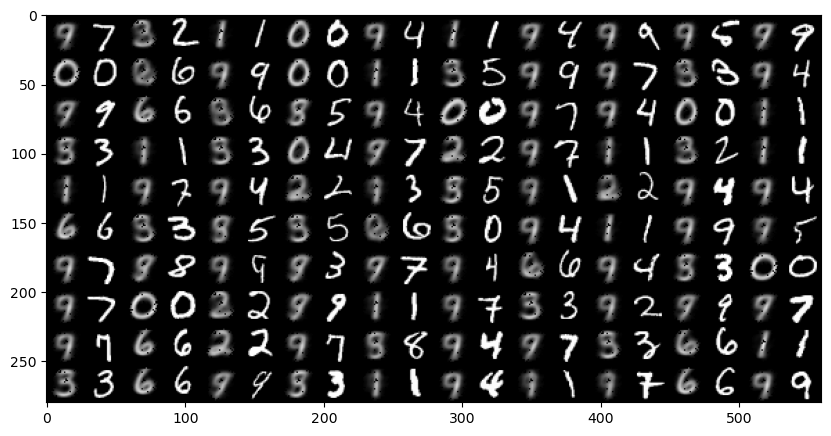

Epoch 29 - 99% - 	Tot=744.87469 	CE=652.05591 	KL=92.81881550

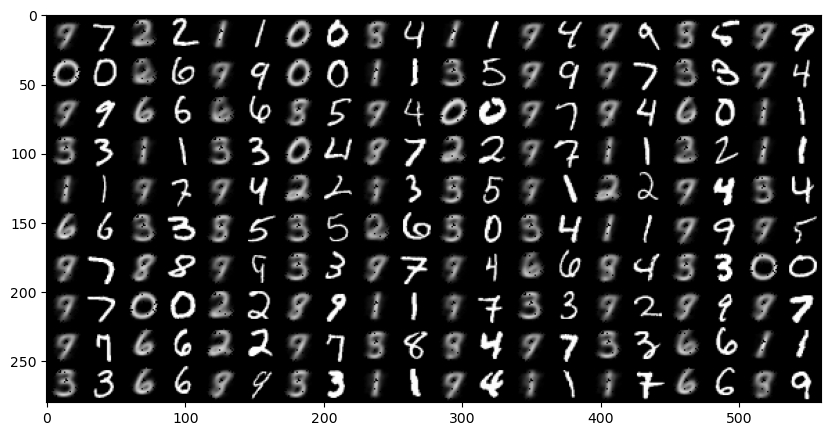

In [11]:
(train_loss, train_ce, train_kl, test_loss, test_ce, test_kl) =\
train_procedure(my_VAE, train_dataset, test_dataset, n_epochs=30, batch_size=64)

**Q10** Draw the evolution of the various losses during training ? Comment the results

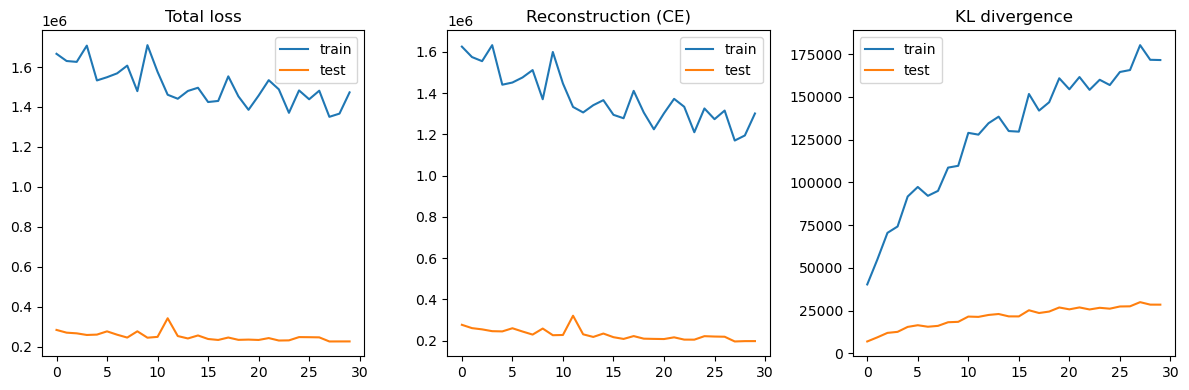

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(train_loss, label="train")
plt.plot(test_loss, label="test")
plt.title("Total loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot([-v for v in train_ce], label="train")
plt.plot([-v for v in test_ce], label="test")
plt.title("Reconstruction (CE)")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(train_kl, label="train")
plt.plot(test_kl, label="test")
plt.title("KL divergence")
plt.legend()

plt.tight_layout()
plt.show()

## VAE as generative model

One of the coolest feature of VAEs is that we forced them to learn a representation whose components are independent. When we visualize them, we can interpret their meanings which sometimes grasps handwriting orientation or curvature. 

Because we choose `d_z = 2`, a visualization in the form of a 2D array of images of digits can be made. We'll just visit the latent space around $\mathbf{z} = [0 \:\: 0]$ with constant sampling period and show the corresponding decoded image.

**Q11** Use the function below to get this visualisation and comment on the result.

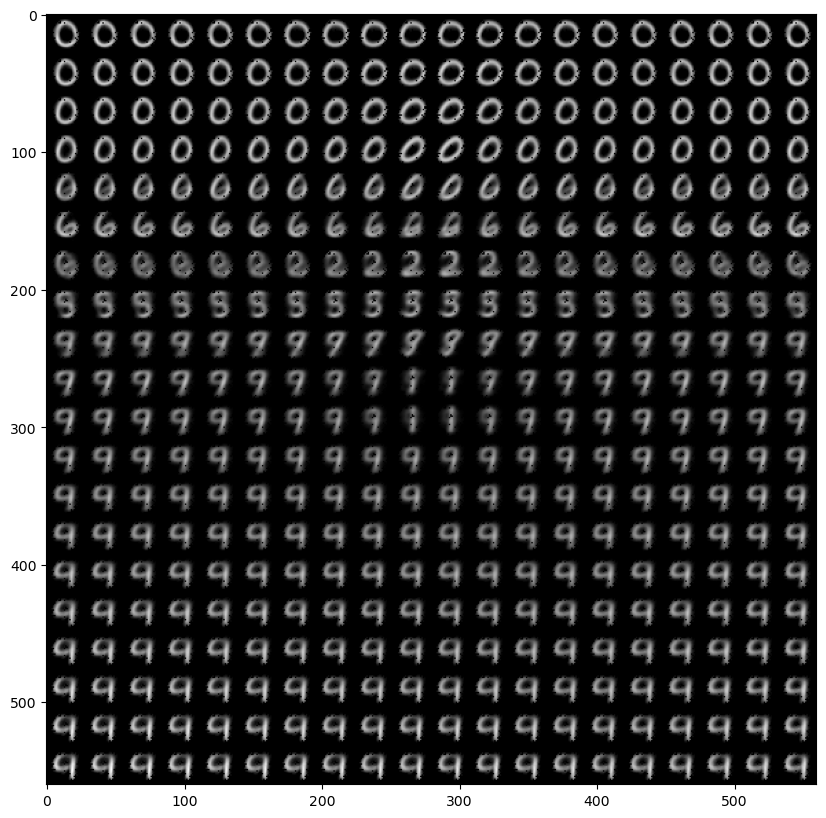

In [13]:
def plot_manifold(imgs,h,w, save_file, dir_name='.'):
    imgs=imgs.detach().numpy()
    imgs_fake = np.reshape(imgs, (-1, h, w))
    h_imgs, w_imgs = int(np.sqrt(imgs_fake.shape[0])), int(np.sqrt(imgs_fake.shape[0]))
    array = _merge(imgs_fake, size=[h_imgs, w_imgs], resize_ratio=1.)
    #imsave(os.path.join(dir_name, save_file+'.png'), array, cmap='gray')
    plt.figure(figsize=(10, 10))
    plt.imshow(array, cmap='gray')
    
def _merge(images, size, resize_ratio=1.):
    h, w = images.shape[1], images.shape[2]
    h_ = int(h * resize_ratio)
    w_ = int(w * resize_ratio)

    img_canvas = np.zeros((h_ * size[0], w_ * size[1]))
    for idx, image in enumerate(images):
        i = int(idx % size[1])
        j = int(idx / size[1])

        image_resize = np.array(Image.fromarray(image).resize((h_, w_), Image.BICUBIC))
        img_canvas[j * h_:j * h_ + h_, i * w_:i * w_ + w_] = image_resize

    return img_canvas

z_range = 3.
z_vectors = torch.tensor(np.rollaxis(np.mgrid[z_range:-z_range:20 * 1j, z_range:-z_range:20 * 1j], 0, 3).reshape([-1, 2]),dtype=torch.float32)
x_decodes = my_VAE.decode(z_vectors)
plot_manifold(x_decodes,h,w, 'manifold')

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0">
    
Key observations:
- The decoded images vary smoothly and continuously across the grid, indicating that the VAE has learned a well-structured and continuous latent representation.

- Neighboring points in latent space correspond to visually similar digits, which confirms that the decoder generalizes smoothly between latent codes rather than memorizing individual samples.

- Different regions of the latent space specialize in different digit classes. But 9 takes most of the space which indicates that the network is still not trained enough.

</div>